# The same ladder on an independent public dataset

The ladder of notebooks 13 to 17 (what the predictor knows against the margin it needs) comes from one office and six links. Here the same procedure runs on the public urban measurements of González-Palacio et al., the data behind the machine-learning path-loss models for LoRaWAN of Medellín: four fixed end nodes, 930,753 uplinks from October 2021 to March 2022, roughly one a minute, with temperature, humidity, pressure, PM2.5, the spreading factor and the SNR.

Source: the companion data descriptor, https://doi.org/10.3390/data8010004, and the repository `magonzalezudem/MDPI_LoRaWAN_Dataset_With_Environmental_Variables`. The file `LoRaWAN_PathLossMeasurements.csv` from that repository goes into `Data_Files`. It is read unchanged, without the Mahalanobis filter of the original paper, which uses the path loss itself among its variables.

* Same chronological split as notebook 00: the first 80 % of the packets in time for training, five forward-chaining validation blocks inside it, the last 20 % as hold-out. The timestamps are taken as local time, UTC-5.
* The history features are those of `history_features.build`, with the clock in the local time zone. The environmental inputs are the four sensors of the dataset.
* **Static inputs**: distance, frequency, temperature, humidity, pressure, PM2.5. **Static inputs with the SNR of the same packet**: the leaky variant behind the published gains. History rungs as in notebook 13: H1 link history; H4 adds the same-channel history, the clock and the spreading factor; H6 adds the SNR of earlier packets and the sensors; H7 adds the link level and the distance.
* One LightGBM per rung, tuned on rung H4 as in notebook 13. The 99 % margin is one shift from the out-of-fold scores of the validation blocks. Notebook 17's four main methods are repeated on rung H4.

In [1]:
import json
import time
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from history_features import build, H1, H2, H3, H4, H5
from margin_tools import pinball, shift_pooled, shift_groups, aci, spread_groups, day_codes, boot_stat, transitions, clustering_ratio

RANDOM_STATE = 42
TAU = 0.99

In [2]:
# The public file, as released
raw = pd.read_csv("Data_Files/LoRaWAN_PathLossMeasurements.csv")
df = pd.DataFrame({"device_id": raw["device_id"],
                   "t": pd.to_datetime(raw["timestamp"], dayfirst=True, format="mixed").dt.tz_localize("America/Bogota").dt.tz_convert("UTC"),
                   "PL": raw["experimental_pl"], "frequency": raw["frequency"] / 1e6, "SF": raw["sf"], "snr": raw["snr"], "distance": raw["distance"],
                   "temperature": raw["temperature"], "rh": raw["rh"], "bp": raw["bp"], "pm2_5": raw["pm2_5"]})
df = df.sort_values("t").reset_index(drop=True)

# The chronological split and the forward-chaining folds of notebook 00 (fold -1 = first training block, 0-4 = validation blocks, 9 = hold-out)
split = int(len(df) * 0.8)
fold = np.full(len(df), 9)
fold[:split] = -1
for k, (_, va) in enumerate(TimeSeriesSplit(n_splits=5).split(df.iloc[:split])):
    fold[va] = k
df["fold"] = fold
print(df.groupby("device_id").agg(packets=("PL", "size"), first=("t", "min"), last=("t", "max"), distance=("distance", "first"), PL_mean=("PL", "mean"), PL_sd=("PL", "std")).round(2))
print(f"training {split:,} packets up to {df['t'].iloc[split - 1]}, hold-out {len(df) - split:,} packets from {df['t'].iloc[split]}; hold-out links: {sorted(df.loc[fold == 9, 'device_id'].unique())}")

           packets                     first                      last  \
device_id                                                                
EN1         201595 2021-11-04 21:24:00+00:00 2022-03-24 21:18:00+00:00   
EN2         183042 2021-10-12 21:33:00+00:00 2022-02-17 00:14:00+00:00   
EN3         344688 2021-10-01 16:34:00+00:00 2022-03-30 05:09:00+00:00   
EN4         201428 2021-11-05 13:22:00+00:00 2022-03-25 10:29:00+00:00   

           distance  PL_mean  PL_sd  
device_id                            
EN1            2140    92.58   2.18  
EN2            3450    99.49   2.82  
EN3            6100   105.26   2.48  
EN4            8260   109.06   2.16  
training 744,602 packets up to 2022-02-16 13:01:00+00:00, hold-out 186,151 packets from 2022-02-16 13:01:00+00:00; hold-out links: ['EN1', 'EN2', 'EN3', 'EN4']


In [3]:
# History features and rungs
d = build(df, tz="America/Bogota").sort_values("t").reset_index(drop=True)
fold = d["fold"].to_numpy()
SENSORS = ["temperature", "rh", "bp", "pm2_5"]
rungs = {"H1": H1, "H4": H4, "H6": H5 + SENSORS, "H7": H5 + SENSORS + ["a", "distance"]}
static = ["distance", "frequency"] + SENSORS
ok = (d["y"].notna() & d[rungs["H7"]].notna().all(axis=1)).to_numpy()
y, a, PL = d["y"].to_numpy(), d["a"].to_numpy(), d["PL"].to_numpy()
link, sf, work, s20 = d["device_id"].to_numpy(), d["SF"].to_numpy().astype(int), d["work"].to_numpy().astype(int), d["s20"].to_numpy()
day = day_codes(d["t"])
val, ev = ok & (fold >= 0) & (fold < 9), ok & (fold == 9)
X_all = d[sorted(set(sum(rungs.values(), []) + static + ["snr"]))]
X_all = X_all.fillna(X_all[ok & (fold < 9)].median())
print(f"packets with an anchor and a complete input: {ok.sum():,} of {len(d):,}; validation {val.sum():,}; hold-out {ev.sum():,}")

packets with an anchor and a complete input: 929,953 of 930,753; validation 620,500; hold-out 186,151


In [4]:
# One light search on rung H4, every tenth row, as in notebook 13; the same settings for every rung
sub = np.flatnonzero(ok & (fold < 9))[::10]
cv_sub = [(np.flatnonzero(fold[sub] < k), np.flatnonzero(fold[sub] == k)) for k in range(5)]
space = {"num_leaves": Integer(15, 255), "learning_rate": Real(0.01, 0.2, prior="log-uniform"), "n_estimators": Integer(200, 1500), "min_child_samples": Integer(20, 1000),
         "subsample": Real(0.6, 1.0), "colsample_bytree": Real(0.5, 1.0), "reg_lambda": Real(0.1, 30, prior="log-uniform")}
t0 = time.time()
bs = BayesSearchCV(lgb.LGBMRegressor(subsample_freq=1, random_state=RANDOM_STATE, n_jobs=4, verbose=-1), space, n_iter=20, cv=cv_sub, scoring="neg_root_mean_squared_error",
                   n_jobs=8, n_points=2, random_state=RANDOM_STATE, refit=False)
bs.fit(X_all[rungs["H4"]].to_numpy()[sub], y[sub])
best = dict(bs.best_params_)
json.dump(best, open("CV_Results/medellin_best_params.json", "w"), indent=1, default=float)
print(f"search RMSE {-bs.best_score_:.3f} dB after {time.time() - t0:.0f} s: {best}")
params = dict(subsample_freq=1, random_state=RANDOM_STATE, n_jobs=8, verbose=-1, **best)

def oof_and_test(make, cols, target):
    X = X_all[cols].to_numpy()
    p = np.full(len(d), np.nan)
    for k in range(5):
        tr, va = ok & (fold < k), ok & (fold == k)
        p[va] = make().fit(X[tr], target[tr]).predict(X[va])
    p[ev] = make().fit(X[ok & (fold < 9)], target[ok & (fold < 9)]).predict(X[ev])
    return p

search RMSE 1.345 dB after 36 s: {'colsample_bytree': 0.6172471797302971, 'learning_rate': 0.011275413328509586, 'min_child_samples': 20, 'n_estimators': 1245, 'num_leaves': 42, 'reg_lambda': 24.669325871150225, 'subsample': 0.763318453996164}


In [5]:
# The ladder: predicted path loss for every rung, and the references that need no model
pred = {}
t0 = time.time()
mean = np.full(len(d), np.nan)                                       # the mean of each link over the earlier training packets
for k in list(range(5)) + [9]:
    earlier = d[ok & (fold < k)] if k < 9 else d[ok & (fold < 9)]
    mean[fold == k] = d.loc[fold == k, "device_id"].map(earlier.groupby("device_id")["PL"].mean())
pred["per-link mean"] = mean
pred["previous hour mean"] = a
pred["static inputs"] = oof_and_test(lambda: lgb.LGBMRegressor(**params), static, PL)
pred["static inputs + SNR of the same packet"] = oof_and_test(lambda: lgb.LGBMRegressor(**params), static + ["snr"], PL)
for name, cols in rungs.items():
    pred[f"rung {name}"] = a + oof_and_test(lambda: lgb.LGBMRegressor(**params), cols, y)
print(f"{time.time() - t0:.0f} s")

te = np.flatnonzero(ev)
dd = pd.factorize(day[te])[0]
rmse = lambda e: float(np.sqrt(np.mean(np.square(e))))
rows = []
for name, p in pred.items():
    e = PL - p
    c = shift_pooled(e[val & np.isfinite(e)], TAU)
    r = boot_stat(dd, np.column_stack([e[te] ** 2, np.ones(len(te))]), lambda T: np.sqrt(T[:, 0] / T[:, 1]))
    rows.append({"inputs": name, "hold-out RMSE": r[0], "lo": r[1], "hi": r[2], "validation RMSE": rmse(e[val & np.isfinite(e)]), "99 % shift dB": c, "coverage": float((e[te] <= c).mean()), "pinball x 1000": 1000 * pinball(e[te], c, TAU).mean()})
ladder = pd.DataFrame(rows).set_index("inputs")
ladder.to_csv("CV_Results/medellin_ladder.csv")
display(ladder.round(3))

193 s


,hold-out RMSE,lo,hi,validation RMSE,99 % shift dB,coverage,pinball x 1000
inputs,,,,,,,
per-link mean,2.466,2.339,2.599,2.434,5.735,0.992,63.294
previous hour mean,1.616,1.596,1.634,1.609,3.875,0.987,47.292
static inputs,2.122,2.033,2.216,2.248,5.553,0.996,58.358
static inputs + SNR of the same packet,1.483,1.442,1.523,1.501,3.985,0.994,44.263
rung H1,1.541,1.522,1.558,1.528,3.680,0.989,44.371
rung H4,1.332,1.320,1.344,1.324,2.955,0.988,37.419
rung H6,1.309,1.296,1.321,1.297,2.880,0.989,36.643
rung H7,1.301,1.288,1.315,1.292,2.871,0.989,36.506


In [6]:
# Rung H4 with the margin built four ways, as in notebook 17: a regression with one margin, a regression with a margin per state, a quantile model with one shift, a quantile model with an adaptive shift
X4 = rungs["H4"]
reg = pred["rung H4"] - a
q = oof_and_test(lambda: lgb.LGBMRegressor(objective="quantile", alpha=TAU, **params), X4, y)
windows = [1, 2, 3, 4, 9]
margin, cuts, rows_of = {}, {}, {}
for w in windows:
    t_ = np.flatnonzero(ok & (fold == w))
    cal = np.flatnonzero(ok & (fold >= 0) & (fold < w))
    cut = np.quantile(s20[cal], [1 / 3, 2 / 3])
    rows_of[w], cuts[w] = t_, cut
    g1 = lambda i: (sf[i] - 7) * 2 + work[i]
    g2 = lambda i: g1(i) * 3 + spread_groups(s20[i], cut)
    for kind, b in (("reg", reg), ("q", q)):
        score = y[cal] - b[cal]
        margin[(w, f"{kind} pooled")] = b[t_] + shift_pooled(score, TAU)
        if kind == "reg":
            margin[(w, "reg state table")] = b[t_] + shift_groups(score, g2(cal), g2(t_), TAU)
        else:
            m = np.empty(len(t_))
            for l in np.unique(link[t_]):
                i = np.flatnonzero(link[t_] == l)
                m[i] = aci(b[t_][i], y[t_][i], score, TAU, (1 - TAU) / 20)
            margin[(w, "q ACI")] = m
methods = ["reg pooled", "reg state table", "q pooled", "q ACI"]

rows = []
for w in windows:
    t_ = rows_of[w]
    for method in methods:
        m = margin[(w, method)]
        miss = y[t_] > m
        states = {"all": np.ones(len(t_), bool), "other hours": work[t_] == 0, "working hours": work[t_] == 1, "calm spread": spread_groups(s20[t_], cuts[w]) == 0,
                  "volatile spread": spread_groups(s20[t_], cuts[w]) == 2}
        states.update({f"SF{k}": sf[t_] == k for k in np.unique(sf[t_]) if (sf[t_] == k).sum() >= 1000})
        states.update({str(k): link[t_] == k for k in np.unique(link[t_]) if (link[t_] == k).sum() >= 1000})
        for g, sel in states.items():
            rows.append(dict(window=w, method=method, state=g, n=int(sel.sum()), coverage=1 - miss[sel].mean(), margin=m[sel].mean(), pinball=1000 * pinball(y[t_][sel], m[sel], TAU).mean()))
margins = pd.DataFrame(rows)
margins.to_csv("CV_Results/medellin_margins.csv", index=False)
print("coverage at the 99 % target by window and method, all packets")
display(margins[margins.state == "all"].pivot(index="method", columns="window", values="coverage").loc[methods].round(4))
print("hold-out coverage by state")
display(margins[margins.window == 9].pivot(index="state", columns="method", values="coverage")[methods].round(4))
print("hold-out mean margin above the anchor (dB) and pinball loss x 1000, all packets")
display(margins[(margins.window == 9) & (margins.state == "all")].set_index("method")[["margin", "pinball"]].loc[methods].round(3))

coverage at the 99 % target by window and method, all packets


window,1,2,3,4,9
method,,,,,
reg pooled,0.9934,0.9919,0.9916,0.9925,0.9882
reg state table,0.9926,0.9916,0.9917,0.9922,0.9890
q pooled,0.9946,0.9936,0.9931,0.9935,0.9905
q ACI,0.9905,0.9903,0.9904,0.9905,0.9900


hold-out coverage by state


method,reg pooled,reg state table,q pooled,q ACI
state,,,,
EN1,0.9884,0.9888,0.9886,0.9899
EN3,0.9861,0.9888,0.9917,0.9901
EN4,0.9912,0.9894,0.9904,0.9900
SF10,0.9873,0.9898,0.9916,0.9904
SF7,0.9958,0.9920,0.9943,0.9941
SF8,0.9912,0.9855,0.9875,0.9880
SF9,0.9810,0.9861,0.9847,0.9862
all,0.9882,0.9890,0.9905,0.9900
calm spread,0.9899,0.9889,0.9908,0.9901


hold-out mean margin above the anchor (dB) and pinball loss x 1000, all packets


,margin,pinball
method,,
reg pooled,2.953,37.419
reg state table,2.926,37.001
q pooled,2.998,36.570
q ACI,2.959,36.496


In [7]:
# Independence of the misses on the hold-out, and the difference between the margins with 95 % intervals from resampling days
t_ = rows_of[9]
dd = pd.factorize(day[t_])[0]
rows = []
for method in methods:
    T = transitions(d["t"].iloc[t_], link[t_], y[t_] > margin[(9, method)])
    r = boot_stat(dd, T, clustering_ratio)
    rows.append(dict(method=method, miss_clustering=r[0], lo=r[1], hi=r[2]))
independence = pd.DataFrame(rows).set_index("method")
display(independence.round(2))
rows = []
for m1, m2 in [("q pooled", "reg pooled"), ("q pooled", "reg state table"), ("q ACI", "q pooled")]:
    diff = pinball(y[t_], margin[(9, m1)], TAU) - pinball(y[t_], margin[(9, m2)], TAU)
    r = boot_stat(dd, np.column_stack([diff, np.ones(len(t_))]), lambda T: 1000 * T[:, 0] / T[:, 1])
    rows.append(dict(a=m1, b=m2, pinball_difference=r[0], lo=r[1], hi=r[2]))
display(pd.DataFrame(rows).round(3))

,miss_clustering,lo,hi
method,,,
reg pooled,2.86,1.99,3.73
reg state table,2.71,1.82,3.68
q pooled,1.84,1.03,2.83
q ACI,1.68,0.87,2.62


,a,b,pinball_difference,lo,hi
0,q pooled,reg pooled,-0.850,-1.162,-0.570
1,q pooled,reg state table,-0.431,-0.662,-0.200
2,q ACI,q pooled,-0.074,-0.154,-0.003


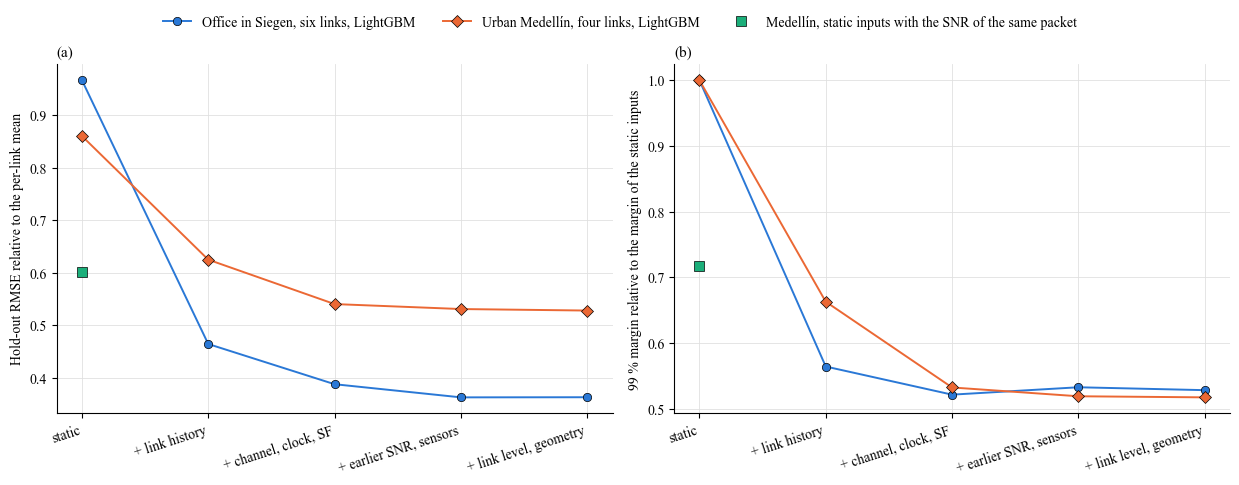

In [8]:
# Figure: the same ladder on both datasets, relative to the per-link mean and to the static margin, with the leaky variant on the public data
siegen = pd.read_csv("CV_Results/information_by_family.csv", index_col=[0, 1]).loc["LGBM"]
mean_siegen = pd.read_csv("CV_Results/history_benchmark.csv", index_col=[0, 1]).loc[("link mean", "-"), "hold-out RMSE"]
labels = ["static", "+ link history", "+ channel, clock, SF", "+ earlier SNR, sensors", "+ link level, geometry"]
s_rmse = [siegen.loc[r, "hold-out RMSE"] / mean_siegen for r in ("static", "H1", "H4", "H6", "H7")]
s_marg = [siegen.loc[r, "margin 0.99"] / siegen.loc["static", "margin 0.99"] for r in ("static", "H1", "H4", "H6", "H7")]
names = ["static inputs", "rung H1", "rung H4", "rung H6", "rung H7"]
m_rmse = [ladder.loc[n, "hold-out RMSE"] / ladder.loc["per-link mean", "hold-out RMSE"] for n in names]
m_marg = [ladder.loc[n, "99 % shift dB"] / ladder.loc["static inputs", "99 % shift dB"] for n in names]
plt.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman", "DejaVu Serif"], "font.size": 10})
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))
for a_, s_, m_, ylab in ((ax[0], s_rmse, m_rmse, "Hold-out RMSE relative to the per-link mean"), (ax[1], s_marg, m_marg, "99 % margin relative to the margin of the static inputs")):
    a_.plot(range(5), s_, "o-", color="#2a78d6", ms=6, mec="black", mew=0.5, lw=1.4, label="Office in Siegen, six links, LightGBM")
    a_.plot(range(5), m_, "D-", color="#eb6834", ms=6, mec="black", mew=0.5, lw=1.4, label="Urban Medellín, four links, LightGBM")
    a_.set_xticks(range(5), labels, rotation=18, ha="right")
    a_.set_ylabel(ylab)
    a_.grid(color="0.88", lw=0.6)
    a_.set_axisbelow(True)
    for sp in ("top", "right"):
        a_.spines[sp].set_visible(False)
leaky = ladder.loc["static inputs + SNR of the same packet"]
ax[0].plot([0], [leaky["hold-out RMSE"] / ladder.loc["per-link mean", "hold-out RMSE"]], "s", color="#1baf7a", ms=7, mec="black", mew=0.5, label="Medellín, static inputs with the SNR of the same packet")
ax[1].plot([0], [leaky["99 % shift dB"] / ladder.loc["static inputs", "99 % shift dB"]], "s", color="#1baf7a", ms=7, mec="black", mew=0.5)
ax[0].set_title("(a)", loc="left", fontsize=11)
ax[1].set_title("(b)", loc="left", fontsize=11)
fig.legend(*ax[0].get_legend_handles_labels(), loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.06))
fig.tight_layout()
fig.savefig("Figures/ladder_two_datasets.png", dpi=300, bbox_inches="tight")
plt.show()

**Reading of the results.**

* **The ladder replicates.** On the public urban data the hold-out RMSE falls from 2.12 dB with the static inputs to 1.54 with the link's history, 1.33 with the same-channel history, the clock and the spreading factor, and 1.31 and 1.30 with the earlier SNR, the sensors and the geometry. The 99 % margin falls from 5.6 to 3.7, 3.0, 2.9 and 2.9 dB, which is 52 to 53 % of the static margin from rung H4 on. In the office the LightGBM reaches 52 to 53 % of its static margin on the same rungs. In both datasets the later rungs add little.
* **The static inputs are worth more here than in the office.** Here they beat the per-link mean by 0.34 dB, 14 %, with the interval of the static RMSE from 2.03 to 2.22 dB. In the office the static LightGBM is 0.17 dB, 3 %, better than its per-link mean.
* **The SNR of the same packet buys what history buys.** Added to the static inputs it lowers the RMSE from 2.12 to 1.48 dB, close to the 1.54 dB of the link's own history, without any earlier packet. This is the gain of the published models. It is leakage: the SNR of a packet is not known before the packet is received.
* **The refinements of the calibration matter little here.** The data hold one regime, spreading factors 7 to 10 throughout. The pooled shift covers between 98.8 and 99.5 % in the five windows, and adaptive conformal inference holds 99.0 to 99.05 %. The quantile model lowers the pinball loss by 0.85 per thousand against the regression with one margin (interval 0.57 to 1.16, 2.3 %) and by 0.43 against the margin per state (interval 0.20 to 0.66, 1.2 %). Misses cluster less with the quantile model and the adaptive shift, 1.7 (interval 0.9 to 2.6), than with the regression and one margin, 2.9 (interval 2.0 to 3.7).
* **Limits.** Four links, one outdoor urban setting, a hold-out of six weeks, and timestamps taken as local time. The office margins are the pooled margins of notebook 16, the public ones the single shift of this notebook, so only the shape of the two ladders is compared.